In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/colab đại học/môn python/scoring_data.csv')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


Dự án "Nghiên cứu độ tin cậy của người vay"

I. Mô tả dữ liệu

children – số lượng con trong gia đình

days_employed – tổng thời gian làm việc (theo ngày)

dob_years – tuổi của khách hàng (theo năm)

education – trình độ học vấn của khách hàng

education_id – mã định danh của trình độ học vấn

family_status – tình trạng hôn nhân

family_status_id – mã định danh của tình trạng hôn nhân

gender – giới tính của khách hàng

income_type – loại hình nghề nghiệp / thu nhập

debt – đã từng nợ quá hạn khi trả khoản vay hay chưa

total_income – thu nhập hàng tháng

purpose – mục đích vay vốn

Mỗi dòng trong bảng là dữ liệu về một khách hàng vay vốn của ngân hàng. Một số cột mô tả thông tin khách hàng. Các cột education_id và family_status_id đóng vai trò chuyển đổi đặc điểm định tính của khách hàng thành định lượng, tức là gán nhãn tương ứng cho tình trạng hôn nhân và trình độ học vấn. Vì vậy, nhìn chung có thể nói dữ liệu ở cột education và family_status đã được sao chép thông qua mã định danh định lượng tương ứng và có thể loại bỏ khỏi bộ dữ liệu do không mang thêm thông tin hữu ích. Các cột debt và purpose mô tả khách hàng trong quy trình cấp tín dụng, phản ánh lịch sử tín dụng của họ.

II. Tiền xử lý dữ liệu

1. Để phát hiện dữ liệu thiếu, sử dụng phương thức isna(). Rồi tính tổng số giá trị thiếu bằng phương thức sum(). Điền chúng bằng giá trị trung vị (median) của cột đó. Đánh giá tỷ lệ giá trị thiếu trong mỗi cột và giải thích tại sao điền bằng trung vị là lựa chọn tối ưu cho các biến định lượng.  

2. Chuyển đổi kiểu dữ liệu số thực (float) trong cột total_income thành kiểu số nguyên (integer). Có thể sử dụng phương thức astype(). Kiểm tra các dòng trùng lặp (duplicates). Nếu có, hãy xóa chúng.

3. Xử lý các giá trị chữ bị in hoa trong cột education có các giá trị giống nhau nhưng được ghi khác kiểu chữ hoa / chữ thường. Hãy chuẩn hóa về cùng một dạng chữ. Kiểm tra tương tự với các cột còn lại.

4. Các tứ phân vị chia một tập dữ liệu đã được sắp xếp thành bốn phần. vẽ biểu đồ boxplot miêu tả và violin (trong đó có tham số hue cho phép nghiên cứu phân phối dưới góc nhìn của một đặc trưng khác)

5. Xử lý các giá trị outliers trong 4 cột float và int và chỉ ra nguyên nhân có thể dẫn đến dữ liệu như vậy (ví dụ: số ngày làm việc âm trong cột days_employed).

6. Dựa trên các khoảng dưới đây, hãy tạo cột total_income_category với các phân loại:
0–30.000 → E
30.001–50.000 → D
50.001–200.000 → C
200.001–1.000.000 → B
1.000.001 trở lên → A

54


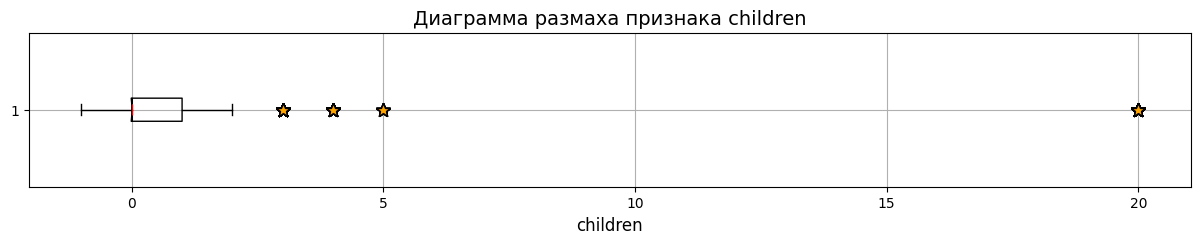

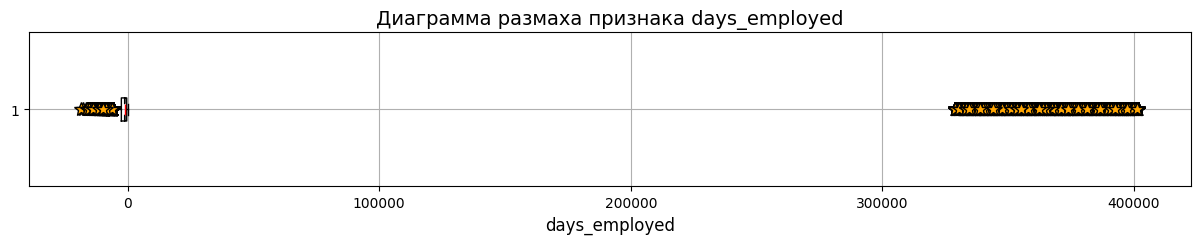

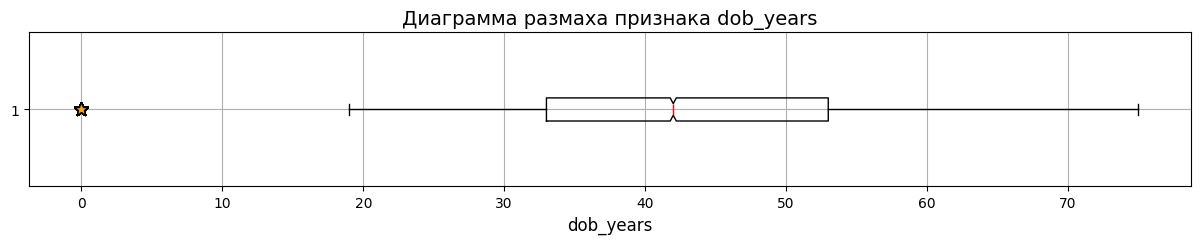

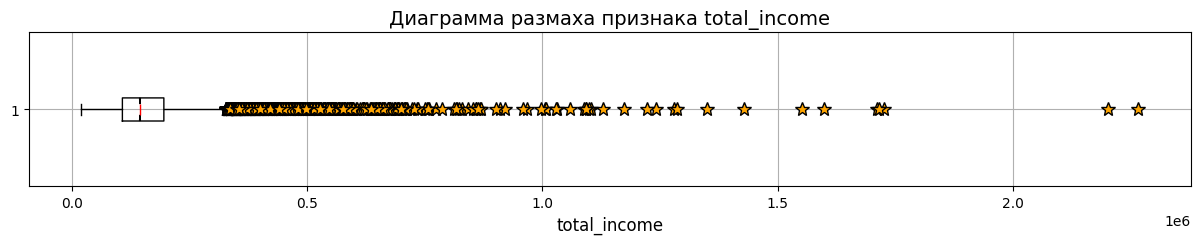

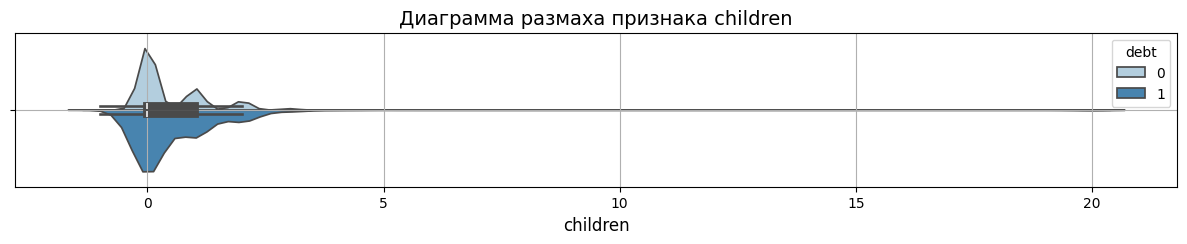

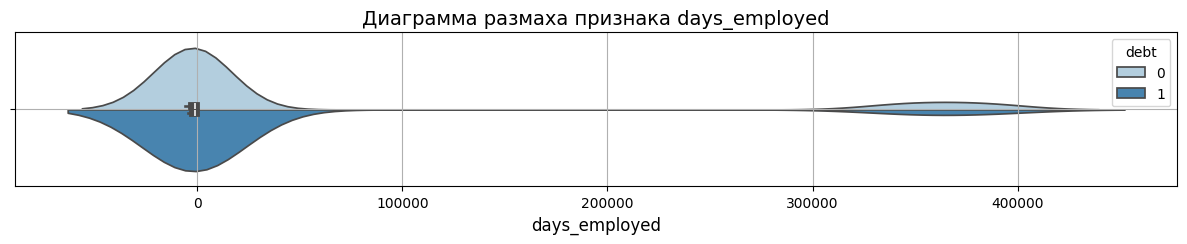

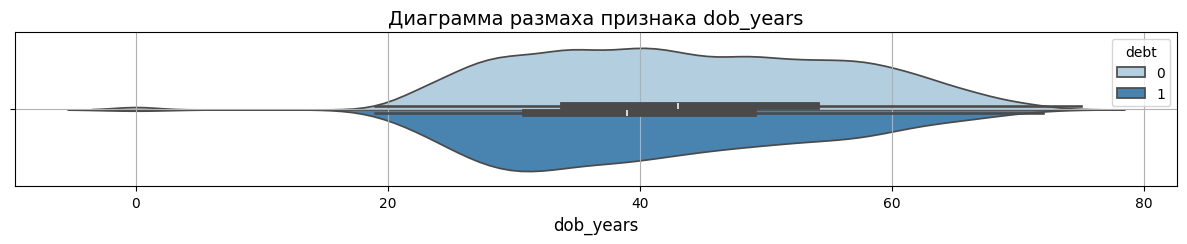

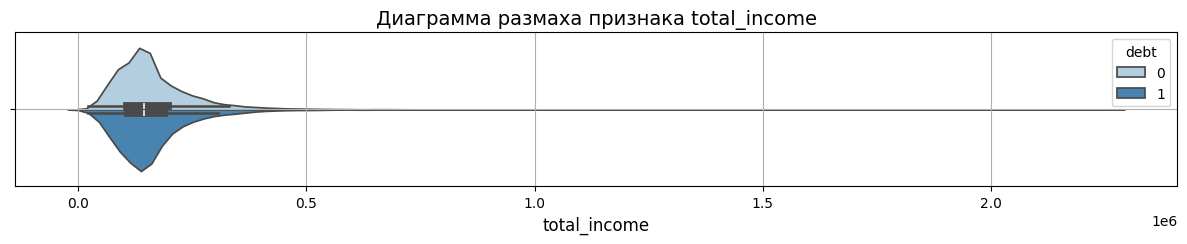

total_income_category
C    13179
B     4438
D      184
A       25
E        7
Name: count, dtype: int64


In [2]:
# II: Tiền xử lý dữ liệu
#1 xử lý dữ liệu null
# df.info()
df.isnull().sum()
df.isnull().sum()/len(df)
#điền bằng median
df.fillna({'days_employed': df['days_employed'].median(),
           'total_income': df['total_income'].median()}, inplace=True)
#2 chuyển đổi kiểu số thực sang số nguyên; xử lý dòng lặp
df['total_income']= df['total_income'].astype('int')
df['total_income'].dtypes
print(df.duplicated().sum())
df.drop_duplicates(ignore_index=True,inplace =True)
#3 xử lý giá trị dạng chữ hoa sang chữ thường, nó vẫn được coi ko phải là duplicate vì có viết hoa
df['education']= df['education'].str.lower()
df['family_status'].unique()
df['family_status']= df['family_status'].str.lower()
#4 vẽ biểu đồ boxplot cho 4 biến float và int
#cách 1
# fig,ax= plt.subplots(2,2,figsize=(15,7))
# ax[0,0].boxplot(df['children'],vert=False,notch=True,flierprops={'marker':'*','markerfacecolor': 'orange','markersize': 10},
#               medianprops={'color': 'red', 'linewidth': 2})
# ax[0,1].boxplot(df['days_employed'],vert=False,notch=True,flierprops={'marker':'*','markerfacecolor': 'orange','markersize': 10},
#               medianprops={'color': 'red', 'linewidth': 2})
# ax[1,0].boxplot(df['dob_years'],vert=False,notch=True,flierprops={'marker':'*','markerfacecolor': 'orange','markersize': 10},
#               medianprops={'color': 'red', 'linewidth': 2})
# ax[1,1].boxplot(df['total_income'],vert=False,notch=True,flierprops={'marker':'*','markerfacecolor': 'orange','markersize': 10},
#               medianprops={'color': 'red', 'linewidth': 2})

#cách 2
col_list = ['children', 'days_employed', 'dob_years', 'total_income']
for name in col_list:
    fig = plt.figure(figsize = (15,2))
    ax = fig.add_subplot()
    ax.boxplot(df[name],vert=False,notch=True,flierprops={'marker':'*','markerfacecolor': 'orange','markersize': 10}, medianprops={'color': 'red'})
    plt.title(f"Диаграмма размаха признака {name}", fontsize=14)
    plt.xlabel(name,fontsize=12)
    plt.grid(0.2)
    plt.show()

# vẽ violin
col_list = ['children', 'days_employed', 'dob_years', 'total_income']
for name in col_list:
    fig = plt.figure(figsize = (15,2))
    sns.violinplot(x=df[name], hue=df['debt'], split=True,palette='Blues') #split để tách 2 nửa, không là nó chồng lên nhau
    plt.title(f"Диаграмма размаха признака {name}", fontsize=14)
    plt.xlabel(name,fontsize=12)
    plt.grid(0.2)
    plt.show()

#5 xử lý outlier và các giá trị vô nghĩa ví dụ số ngày làm việc bị âm (lưu ý để ktra ta vẽ boxplot là đã thấy outlier )
#nguyên nhân: Sai sót nhập liệu: Nhầm dấu, thiếu số, định dạng sai; Lỗi hệ thống: Khi chuyển đổi dữ liệu giữa các hệ thống
len(df[df['days_employed']<0])/len(df) # số samples có ngày làm việc < 0 chiếm hơn 80% nên ta sẽ không xóa
df['days_employed']= df['days_employed'].abs() # để khỏi phải xóa
df[df['gender']=='XNA'].shape[0]/df.shape[0] # kiểm tra giới tính thứ 3 số lượng ít nên xóa luôn
df= df[(df['children'].between(0, 10)) & (df['dob_years'].between(18, 90)) & (df['days_employed']< 22000) & (df['gender']!='XNA')]

#6
bins = [0, 30000, 50000, 200000, 1000000, 100**100]
labels = ['E', 'D', 'C', 'B', 'A']
df['total_income_category'] = pd.cut(df['total_income'], bins=bins, labels=labels, right=True)
print(df['total_income_category'].value_counts())

III. Tìm mối quan hệ giữa việc trả nợ đúng hạn và các yếu tố bằng cách trả lời các câu hỏi sau:

1. mối quan hệ giữa số lượng con và việc trả nợ đúng hạn

2. mối quan hệ giữa tình trạng hôn nhân và việc trả nợ đúng hạn

3. mối quan hệ giữa mức thu nhập và việc trả nợ đúng hạn

4. mối quan hệ giữa trình độ học vấn và việc trả nợ đúng hạn

Cần trình bày dưới dạng bảng tổng hợp (pivot) và vẽ biểu đồ.

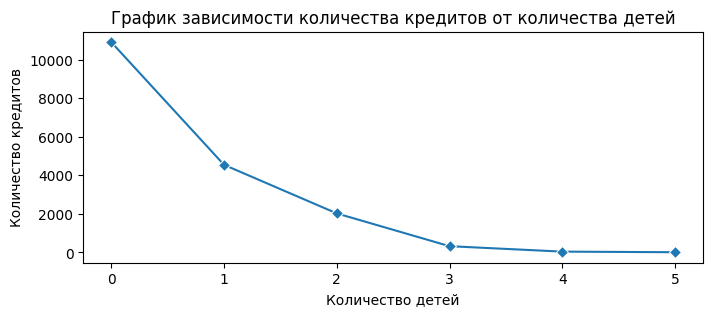

   children      debt
0         0  0.081835
1         1  0.094493
2         2  0.094955
3         3  0.080745
4         4  0.100000
5         5  0.000000
   children  tong_so_nguoi  so_nguoi_no  ty_le_no
0         0          10900          892  0.081835
1         1           4540          429  0.094493
2         2           2022          192  0.094955
3         3            322           26  0.080745
4         4             40            4  0.100000
5         5              9            0  0.000000
   So_con  Ty_le_no
0       0  0.081835
1       1  0.094493
2       2  0.094955
3       3  0.080745
4       4  0.100000
5       5  0.000000


In [3]:
# mỗi ý cần vẽ đồ thị và pivot table
#1 Mối quan hệ giữa việc trả nợ và số lượng con

data_ch=df.groupby('children').count().reset_index() # chỉ cho biết số lượng ng vay theo từng số con chứ ko bt tỷ lệ nợ
# vẽ bằng sns
plt.figure(figsize=(8,3))
sns.lineplot(x=data_ch['children'], y=data_ch['debt'], marker='D')
plt.title('График зависимости количества кредитов от количества детей')
plt.xlabel('Количество детей')
plt.ylabel('Количество кредитов')
plt.show()

#group bảng theo children rồi tính tỉ lệ trung bình theo nợ
so_con = df.groupby('children')['debt'].mean().reset_index() #dùng mean là ra tỷ lệ nợ trong tổng số ng vay vì (0+1+1+0)/4 thì ra 0.5
print(so_con)
#dùng agg trực quan hơn, tạo thêm 2 cột count sum cho dễ thấy phép chia
con = df.groupby('children')['debt'].agg(
    tong_so_nguoi='count',   # Tổng số người trong nhóm
    so_nguoi_no='sum', # các cột debt nhận giá trị 1 mới tính vô sum -> có đc tổng số ng vỡ nợ
    ty_le_no='mean'
).reset_index()
print(con)
# kết luận: tỷ lệ vỡ nợ cao nhất là nhà có 4 con va thấp nhất là nhà có 5 con
# dùng pivot
con_pivot = df.pivot_table(
    values='debt', # tính toán theo debt
    index='children', # Hàng là số con tức group theo số con
    aggfunc='mean' # Tính trung bình = tỷ lệ nợ
).reset_index()
con_pivot.columns = ['So_con','Ty_le_no'] #đặt tên cho pivot
print(con_pivot)

           family_status   debt               
                          count      mean  sum
0              в разводе    983  0.074262   73
1         вдовец / вдова    470  0.065957   31
2       гражданский брак   3548  0.099775  354
3        женат / замужем  10359  0.079641  825
4  не женат / не замужем   2473  0.105135  260
                       count      mean  sum
family_status                              
в разводе                983  0.074262   73
вдовец / вдова           470  0.065957   31
гражданский брак        3548  0.099775  354
женат / замужем        10359  0.079641  825
не женат / не замужем   2473  0.105135  260


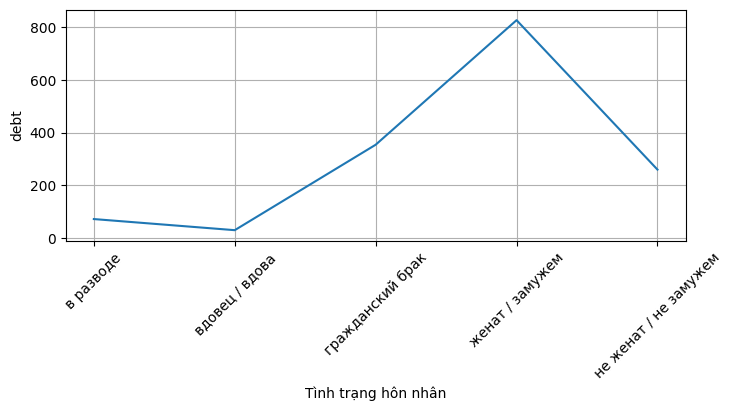

In [4]:
#2 Mối quan hệ giữa việc trả nợ và tình trạng hôn nhân
hon_nhan = df.groupby(by = 'family_status').agg({
    'debt':['count','mean','sum']
}).reset_index()
print(hon_nhan)
# dùng bảng pivot
hon_nhan_pivot = df.pivot_table(
    index = 'family_status',
    values= 'debt',
    aggfunc= {'debt':['count','mean','sum']}
)
print(hon_nhan_pivot)
# có thể nói rằng những người vay kém trách nhiệm nhất có thể được coi là
# những người đang sống chung như vợ chồng không đăng ký kết hôn hoặc những người chưa kết hôn.

fig = plt.figure(figsize=(8,3))
plt.plot(hon_nhan_pivot.index,hon_nhan_pivot['sum'])
plt.xlabel('Tình trạng hôn nhân')
plt.ylabel('debt')
plt.xticks(rotation=45)
plt.grid(0.3)
plt.show()

count    1.629000e+04
mean     1.712805e+05
std      1.004147e+05
min      2.136700e+04
25%      1.136730e+05
50%      1.450170e+05
75%      2.013402e+05
max      2.265604e+06
Name: total_income, dtype: float64
count    1.543000e+03
mean     1.639778e+05
std      1.000118e+05
min      3.394100e+04
25%      1.104740e+05
50%      1.450170e+05
75%      1.893750e+05
max      2.200852e+06
Name: total_income, dtype: float64


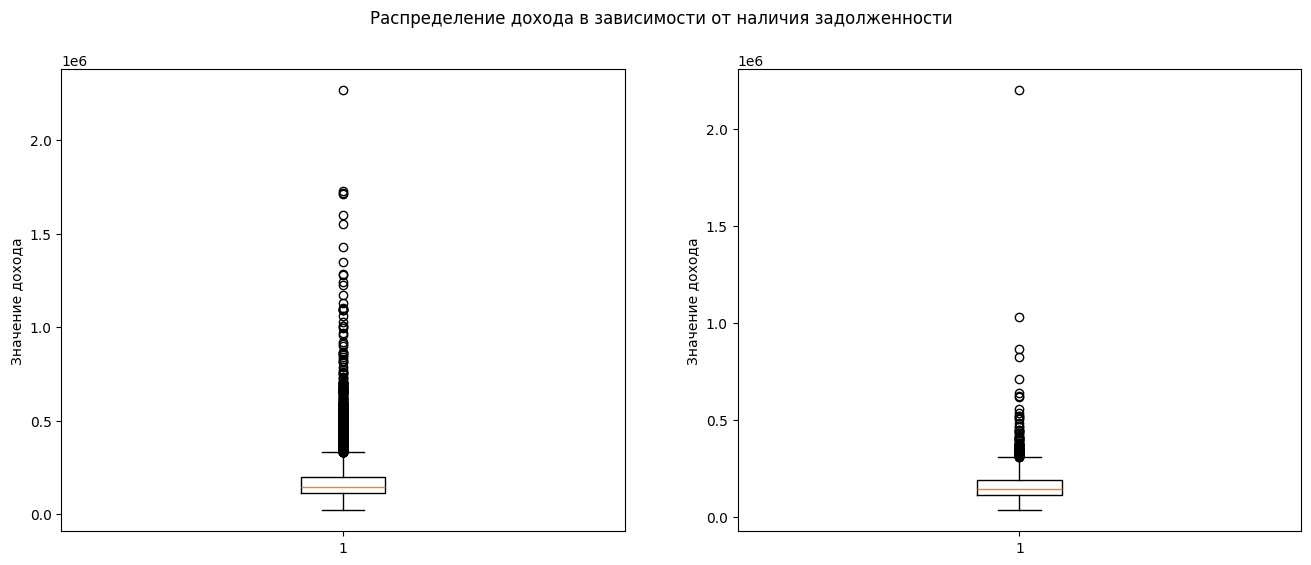

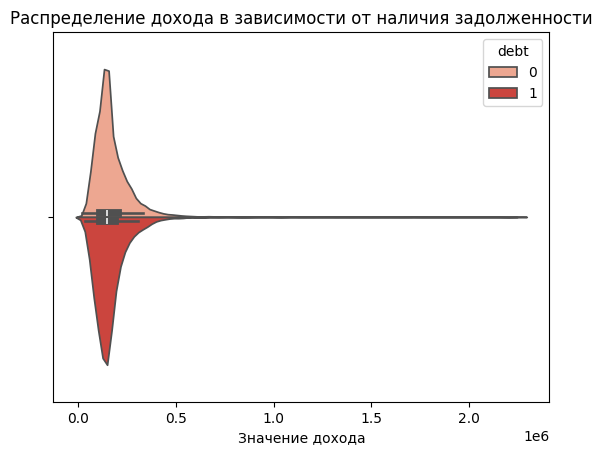

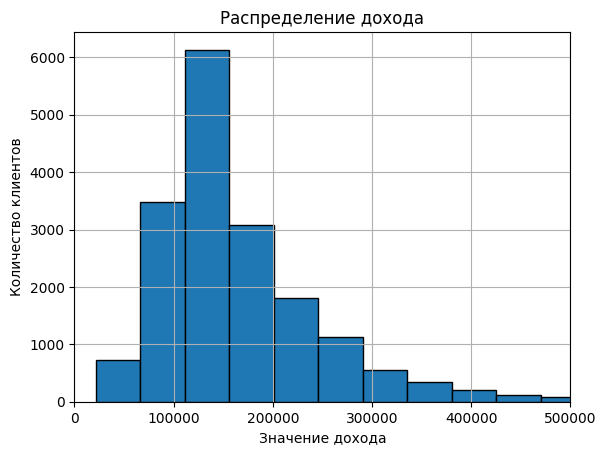

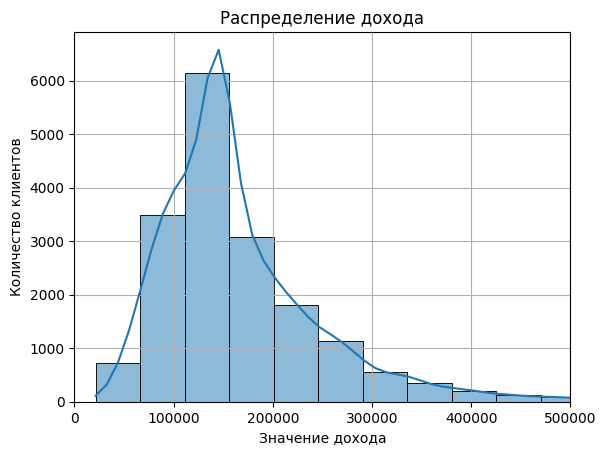

                       count      mean   sum
total_income_category                       
A                         25  0.080000     2
B                       4438  0.072555   322
C                      13179  0.091433  1205
D                        184  0.076087    14
E                          7  0.000000     0


In [8]:
# 3. mối quan hệ giữa mức thu nhập và việc trả nợ đúng hạn
# không làm theo kiểu chia từng nhóm như với biến phân loại
# Ý tưởng: tạo 2 nhóm: Nhóm 1 là người có nợ (debt == 1), nhóm 2 người không có nợ (debt == 0)
# Sau đó so sánh phân phối thu nhập của 2 nhóm này bằng describe
# vẽ biểu đồ boxplot, violint, hist và histplot
# dùng total_income_categorical đã tạo để tạo pivot table

no_debt = df[(df['debt']==0)][['total_income','debt']].reset_index().drop('index',axis=1)
debt = df[(df['debt']==1)][['total_income','debt']].reset_index().drop('index',axis=1)
print(no_debt['total_income'].describe())
print(debt['total_income'].describe())
# Về số lượng:
# Không nợ: 16.290 người (chiếm khoảng 91%)
# Có nợ: 1.543 người (chiếm khoảng 9%)

# Về thu nhập trung bình:
# Không nợ: 171.280; Có nợ: 163.978
# Về trung vị (median): Cả 2 nhóm đều bằng nhau: 145.017. Điều này rất thú vị! Trung vị bằng nhau nhưng trung bình khác nhau.

#đơn giản là vẽ 4 biểu đồ phân phối cho biến total_
fig, ax = plt.subplots(1,2,figsize=(16,6))
ax[0].boxplot(no_debt['total_income'])
ax[0].set_ylabel('Значение дохода')
ax[1].boxplot(debt['total_income'])
ax[1].set_ylabel('Значение дохода')
fig.suptitle('Распределение дохода в зависимости от наличия задолженности')
plt.show()
fig = plt.subplot()
sns.violinplot(x=df['total_income'],hue =df['debt'],split=True,palette='Reds')
plt.title('Распределение дохода в зависимости от наличия задолженности')
plt.xlabel('Значение дохода')

fig = plt.figure()
plt.hist(x=df['total_income'], bins = 50, edgecolor = 'black')
plt.xlim(0, 500000)
plt.title('Распределение дохода')
plt.xlabel('Значение дохода')
plt.ylabel('Количество клиентов')
plt.grid(0.4)

fig = plt.figure()
sns.histplot(x=df['total_income'], kde=True, bins = 50)
plt.xlim(0, 500000)
plt.title('Распределение дохода')
plt.xlabel('Значение дохода')
plt.ylabel('Количество клиентов')
plt.grid()
plt.show()

#pivot
thu_nhap_pivot= df.pivot_table(
    values= 'debt',
    index= 'total_income_category',
    aggfunc = {'debt': ['count','mean','sum']}
).sort_values(by='total_income_category',ascending=False)
print(thu_nhap_pivot)

                      debt                
                     count      mean   sum
education                                 
высшее                4677  0.054308   254
начальное              189  0.148148    28
неоконченное высшее    703  0.095306    67
среднее              12260  0.097390  1194
ученая степень           4  0.000000     0
             education  count      mean   sum
0               высшее   4677  0.054308   254
1            начальное    189  0.148148    28
2  неоконченное высшее    703  0.095306    67
3              среднее  12260  0.097390  1194
4       ученая степень      4  0.000000     0


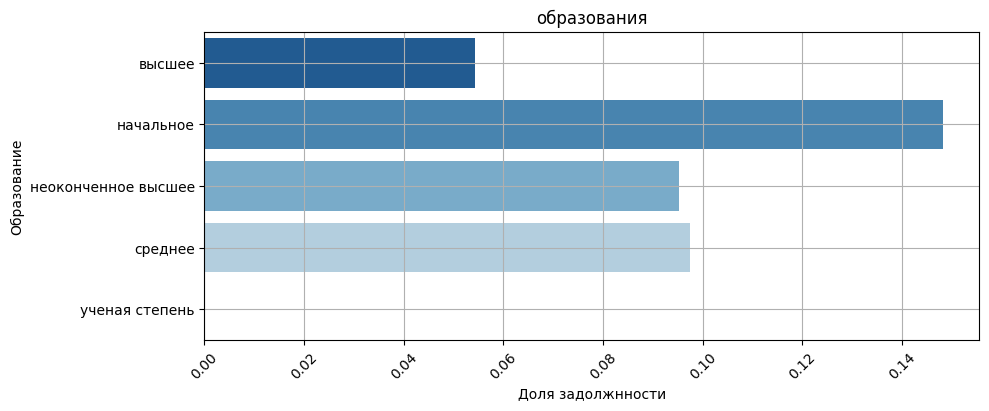

In [7]:
#mối quan hệ giữa trình độ học vấn và việc trả nợ đúng hạn
df['education'].unique()
hoc_van = df.groupby('education').agg({'debt': ['count','mean','sum']})
print(hoc_van)

hoc_van_pivot = df.pivot_table(
    index = 'education',
    values = 'debt',
    aggfunc = {'debt':['count','mean','sum']}
).reset_index()
print(hoc_van_pivot)

# biểu đồ cột ngang
# plt.figure(figsize=(10, 4))
# plt.barh(y= hoc_van_pivot['education'], width = hoc_van_pivot['mean'],alpha = 0.2, color = 'r')
# plt.title('Học vấn')
# plt.xlabel('Tỷ lệ nợ')
# plt.ylabel('Образование')
# plt.grid()

plt.figure(figsize=(10, 4))
sns.barplot(x=hoc_van_pivot['mean'], y=hoc_van_pivot['education'], data=hoc_van_pivot, palette = 'Blues_r')
plt.title('образования')
plt.xlabel('Доля задолжнности')
plt.ylabel('Образование')
plt.xticks(rotation=45)
plt.grid()
plt.show()

Biểu đồ khá trực quan: có thể thấy số lượng khoản vay được cấp giảm dần theo số lượng con trong gia đình người vay. Có thể điều này không phải do các gia đình đông con ít vay tiền hơn. Nhiều khả năng là số lượng gia đình không có con hoặc có 1-2 con nhiều hơn đáng kể so với gia đình đông con. Trong trường hợp này, nên xem xét các giá trị tương đối.

Kết luận
Sau khi phân tích dữ liệu về 4 yếu tố bao gồm: số con, tình trạng hôn nhân, thu nhập, trình độ học vấn, ta rút ra kết luận rằng tất cả các yếu tố này đều có ảnh hưởng đến độ tin cậy của người vay (khả năng trả nợ đúng hạn). Cụ thể, số con càng nhiều thì tỷ lệ nợ càng cao; người có gia đình (kết hôn hoặc góa) trả nợ tốt hơn người độc thân hoặc ly hôn; người có thu nhập cao đặc biệt là nhóm giàu nhất có tỷ lệ nợ thấp hơn; trình độ học vấn càng cao thì tỷ lệ nợ càng thấp (đặc biệt người có học vị không có nợ, người có trình độ tiểu học có tỷ lệ nợ cao nhất). Như vậy, để đánh giá độ tin cậy của người vay, ngân hàng nên đặc biệt chú trọng vào trình độ học vấn và tình trạng hôn nhân vì đây là hai yếu tố thể hiện sự khác biệt rõ rệt nhất giữa nhóm trả nợ tốt và nhóm có nợ quá hạn.